In [1]:
import sys
import os
from pathlib import Path
root = Path().resolve().parent.parent
sys.path.append(str(root))  # Add the root of the |project to the local path

In [2]:
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from nonlinear_models import *
import matplotlib.gridspec as gridspec

%load_ext autoreload
%autoreload 2

In [3]:
with open(os.path.join(experiment_directory, "parameters_round2_null_defaults.json"), "r") as f:
    params = json.load(f)

# Round 2 Results (Figure 4)
This figure emulates the version found in the chaos paper, which encodes many dimensions as a grid of heatmaps.

In [7]:
filename = f"logistic.csv"
table = np.loadtxt(filename, delimiter=",", skiprows=1)

In [6]:
logistic_stuff = np.loadtxt("food_chain.csv", delimiter=",", skiprows=1)

In [8]:
def find_rows_with_values(arr, col_values):
    """
    Find all rows in arr where the first len(col_values) columns match col_values.
    arr: numpy.ndarray
    col_values: list or tuple of values to match in the first columns
    Returns: numpy.ndarray of matching rows
    """
    mask = np.ones(len(arr), dtype=bool)
    for i, val in enumerate(col_values):
        mask &= (arr[:, i] == val)
    return arr[mask]

# Example usage:
# rows = find_rows_with_values(table, [0, 50, 0.1, 0.0])

/home/kengee/miniconda3/envs/NSMapEnv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kengee/miniconda3/envs/NSMapEnv/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/kengee/miniconda3/envs/NSMapEnv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kengee/miniconda3/envs/NSMapEnv/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/kengee/miniconda3/envs/NSMapEnv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/kengee/miniconda3/envs/NSMapEnv/lib/python3.11

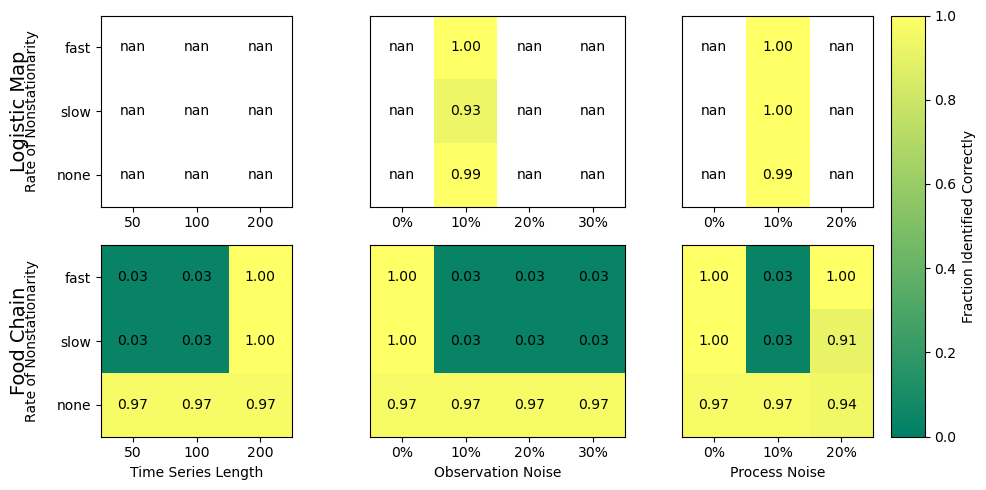

In [9]:
fig = plt.figure(tight_layout=True,figsize=(10,5))
shrink = 0.8
grid = gridspec.GridSpec(2,4, width_ratios=[3,4,2.5,0.4])
nice_variable_names = ["Time Series Length", "Observation Noise","Process Noise"]
nice_model_names = ["Logistic Map", "Food Chain"]
# fig, ax = plt.subplots(2,3)
# plt.tight_layout()

for i, model in enumerate(["logistic", "food_chain"]):

    filename = f"{model}.csv"
    table = np.loadtxt(filename, delimiter=",", skiprows=1)

    experiment_params = params["experiments"][i]["parameters"]

    default_time_series_length = experiment_params["default_length"]
    default_obs_noise = experiment_params["default_obs_noise"]
    default_process_noise = experiment_params["default_process_noise"]

    # Time Series Length Part
    ax_time_series_length = fig.add_subplot(grid[i,0])

    heatmap_time_series_length = np.zeros((3, 3))

    for j, nsrate in enumerate([0, 1, 2]):
        for k, length in enumerate(experiment_params['time_series_length']):
            accuracy = np.mean(find_rows_with_values(table, [nsrate, length, default_obs_noise, default_process_noise])[:, 5])
            accuracy = accuracy if nsrate else 1 - accuracy
            heatmap_time_series_length[j, k] = accuracy
            ax_time_series_length.text(k, nsrate, f"{accuracy:.2f}", ha='center', va='center')

    aximage = ax_time_series_length.imshow(heatmap_time_series_length,vmin=0,vmax=1,cmap='summer')

    ax_time_series_length.set_xticks(np.arange(len(experiment_params['time_series_length'])))
    ax_time_series_length.set_xticklabels(experiment_params['time_series_length'])

    if model == "food_chain":
        ax_time_series_length.set_xlabel(nice_variable_names[0])
    
    ax_time_series_length.set_yticks(np.arange(3))
    ax_time_series_length.set_yticklabels(["none","slow","fast"])
    ax_time_series_length.set_ylim([-0.5, 2.5])
    ax_time_series_length.set_xlim([-0.5, 2.5])
    
    # ax.set_ylabel(nice_model_names[i], labelpad=25, fontsize=12)
    ax_time_series_length.set_ylabel(nice_model_names[i], labelpad = 20, fontsize=14)
    fig.text(-0.325, 0.5, "Rate of Nonstationarity", rotation="vertical", transform=ax_time_series_length.transAxes,
                        horizontalalignment="right", verticalalignment="center")

    # Observation Noise Part
    ax_obs_noise = fig.add_subplot(grid[i,1])
    
    heatmap_obs_noise = np.zeros((3, 4))

    for j, nsrate in enumerate([0, 1, 2]):
        for k, obs_noise in enumerate(experiment_params['obs_noise']):
            accuracy = np.mean(find_rows_with_values(table, [nsrate, default_time_series_length, obs_noise, default_process_noise])[:, 5])
            accuracy = accuracy if nsrate else 1 - accuracy
            heatmap_obs_noise[j, k] = accuracy
            ax_obs_noise.text(k, nsrate, f"{accuracy:.2f}", ha='center', va='center')

    aximage = ax_obs_noise.imshow(heatmap_obs_noise,vmin=0,vmax=1,cmap='summer')

    ax_obs_noise.set_xticks(np.arange(len(experiment_params['obs_noise'])))
    ax_obs_noise.set_xticklabels([f"{int(noise*100)}%" for noise in experiment_params['obs_noise']])

    if model == "food_chain":
        ax_obs_noise.set_xlabel(nice_variable_names[1])
    
    ax_obs_noise.set_yticks([])
    ax_obs_noise.set_ylim([-0.5, 2.5])
    ax_obs_noise.set_xlim([-0.5, 3.5])

    # Process Noise Part
    ax_process_noise = fig.add_subplot(grid[i,2])
    
    heatmap_process_noise = np.zeros((3, 3))
    
    for j, nsrate in enumerate([0, 1, 2]):
        for k, process_noise in enumerate(experiment_params['process_noise']):
            accuracy = np.mean(find_rows_with_values(table, [nsrate, default_time_series_length, default_obs_noise, process_noise])[:, 5])
            accuracy = accuracy if nsrate else 1 - accuracy
            heatmap_process_noise[j, k] = accuracy
            ax_process_noise.text(k, nsrate, f"{accuracy:.2f}", ha='center', va='center')

    aximage = ax_process_noise.imshow(heatmap_process_noise,vmin=0,vmax=1,cmap='summer')

    ax_process_noise.set_xticks(np.arange(len(experiment_params['process_noise'])))
    ax_process_noise.set_xticklabels([f"{int(noise*100)}%" for noise in experiment_params['process_noise']])

    if model == "food_chain":
        ax_process_noise.set_xlabel(nice_variable_names[2])
    
    ax_process_noise.set_yticks([])
    ax_process_noise.set_ylim([-0.5, 2.5])
    ax_process_noise.set_xlim([-0.5, 2.5])

    """
    for j, variable in enumerate(["time_series_length", "obs_noise", "process_noise"]):
        
        # observation noise, nonstationarity status, delta, theta, r_sqrd
        variables = np.unique(table[:,0])
        heatmap = np.zeros((3, len(variables)))

        ax = fig.add_subplot(grid[i,j]) if j < 2 else fig.add_subplot(grid[i,2:3])
        
        for k, val in enumerate(variables):
            for nsrate in range(3):
                accuracy = np.mean(table[np.logical_and(table[:,0] == val,table[:,1] == nsrate),2] > 0.1)
                accuracy = accuracy if nsrate else 1 - accuracy
                heatmap[nsrate,k] = accuracy
                ax.text(k,nsrate,f"{accuracy:.2f}",ha='center',va='center')
        
        aximage = ax.imshow(heatmap,vmin=0,vmax=1,cmap='summer')
        left, right, _, _ = aximage.get_extent()
        
        ax.set_xticks(np.arange(len(variables)))
        if j == 0:
            ax.set_xticklabels(variables.astype(int))
        elif j == 1:
            ax.set_xticklabels(np.array(["0%","10%","20%","30%"]))
        else:
            ax.set_xticklabels(np.array(["0%","10%"]))
        if model == "food_chain":
            ax.set_xlabel(nice_variable_names[j])
        ax.set_yticks(np.arange(3))
        ax.set_yticklabels(["none","slow","fast"])
        ax.set_ylim([-0.5,2.5])
        
        if (j == 0):
            # ax.set_ylabel(nice_model_names[i], labelpad=25, fontsize=12)
            ax.set_ylabel(nice_model_names[i], labelpad = 20, fontsize=14)
            fig.text(-0.325, 0.5, "Rate of Nonstationarity", rotation="vertical", transform=ax.transAxes,
                              horizontalalignment="right", verticalalignment="center")
        """
            
# fig.text(0.07,0.5375,"Rate of Nonstationarity", rotation="vertical",
#          horizontalalignment="center", verticalalignment="center", size=12 )
# plt.tight_layout()
# cax = plt.axes([0.905, 0.09, 0.02, 0.845])
# fig.colorbar(aximage, cax = cax, label = "Fraction Identified Correctly")
colorbar_ax = fig.add_subplot(grid[:,3])
fig.colorbar(aximage, cax = colorbar_ax, 
             label = "Fraction Identified Correctly", 
             shrink=0.1, anchor=(1000,1))
# plt.savefig("../Figures/round2.png", dpi=300)
# plt.savefig("../../figures_eps/round2_results/Figure_4.eps", format="eps", bbox_inches="tight")

# Plot all the different time series types

In [10]:
with open("parameters_round2_null_defaults.json", "r") as f:
    params = json.load(f)

In [11]:
tau = params["tau"]
N_replicates = params["N_replicates"]
resolution = params["resolution"]

experiment_params = params["experiments"][0]["parameters"]

default_length = experiment_params["default_length"]
default_observation_noise = experiment_params["default_obs_noise"]
default_process_noise = experiment_params["default_process_noise"]
nonstat_param_base = experiment_params["nonstat_param_base"]

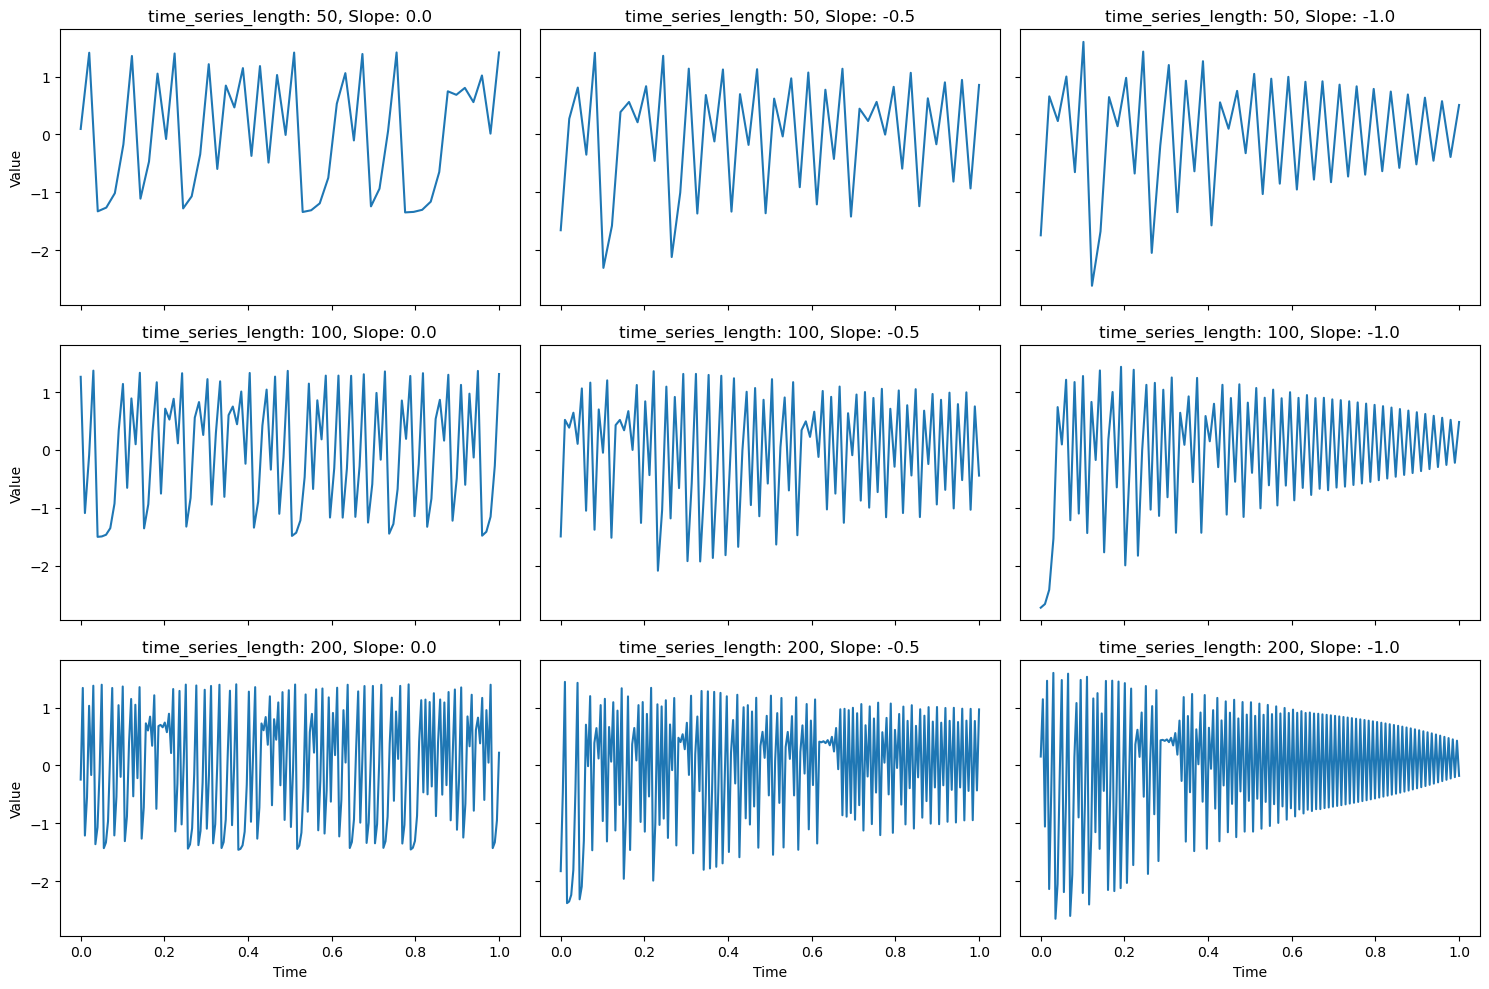

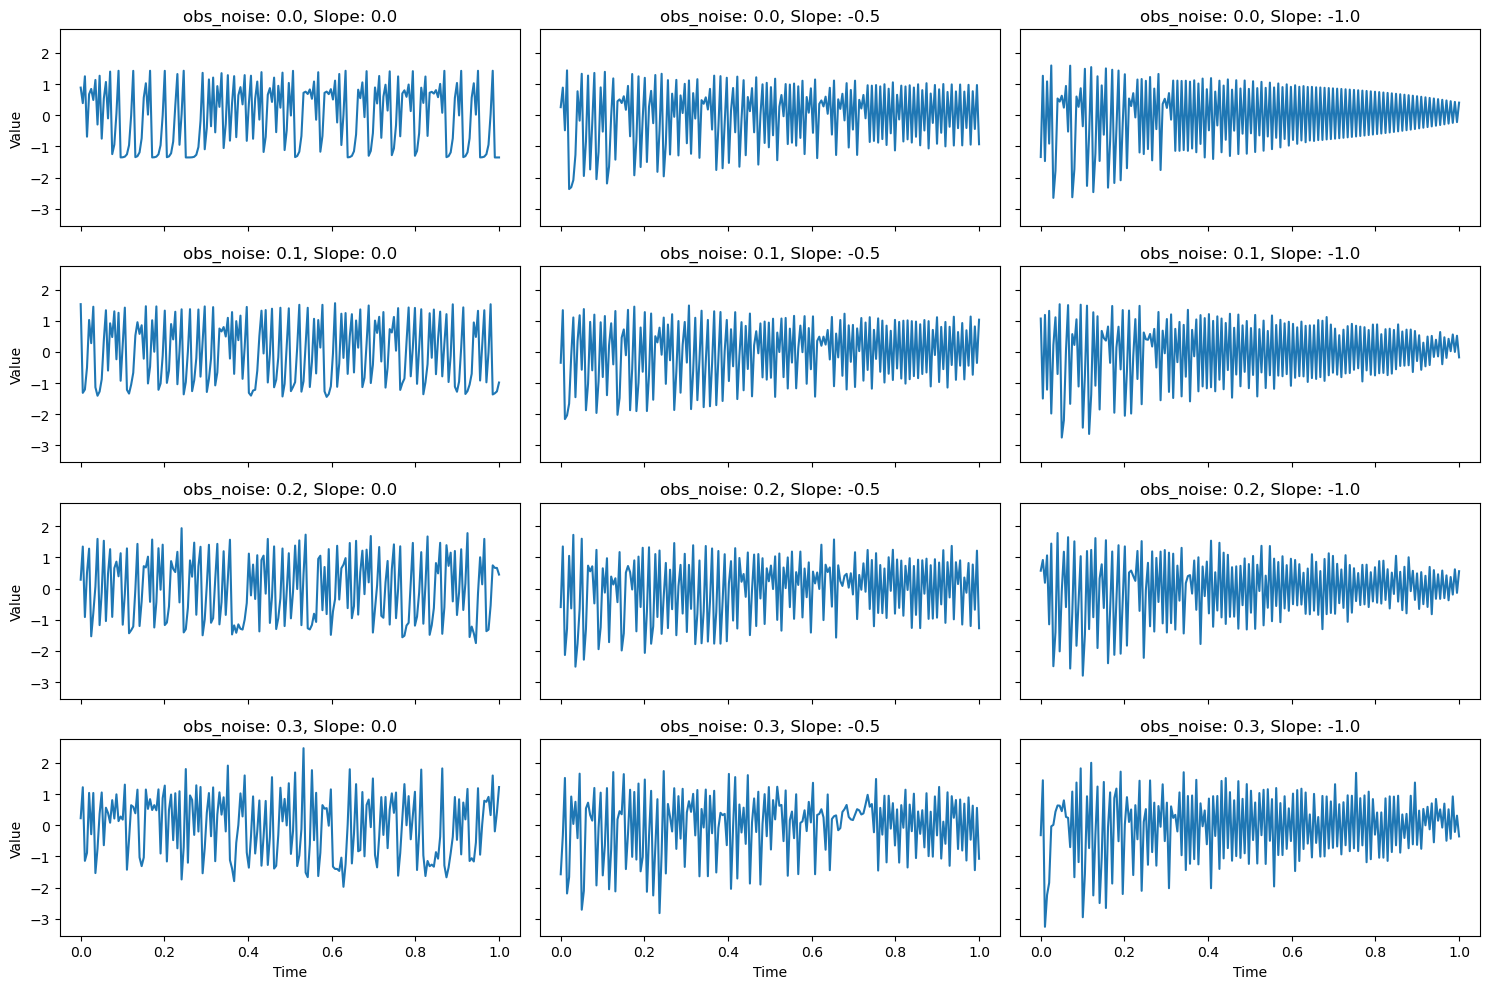

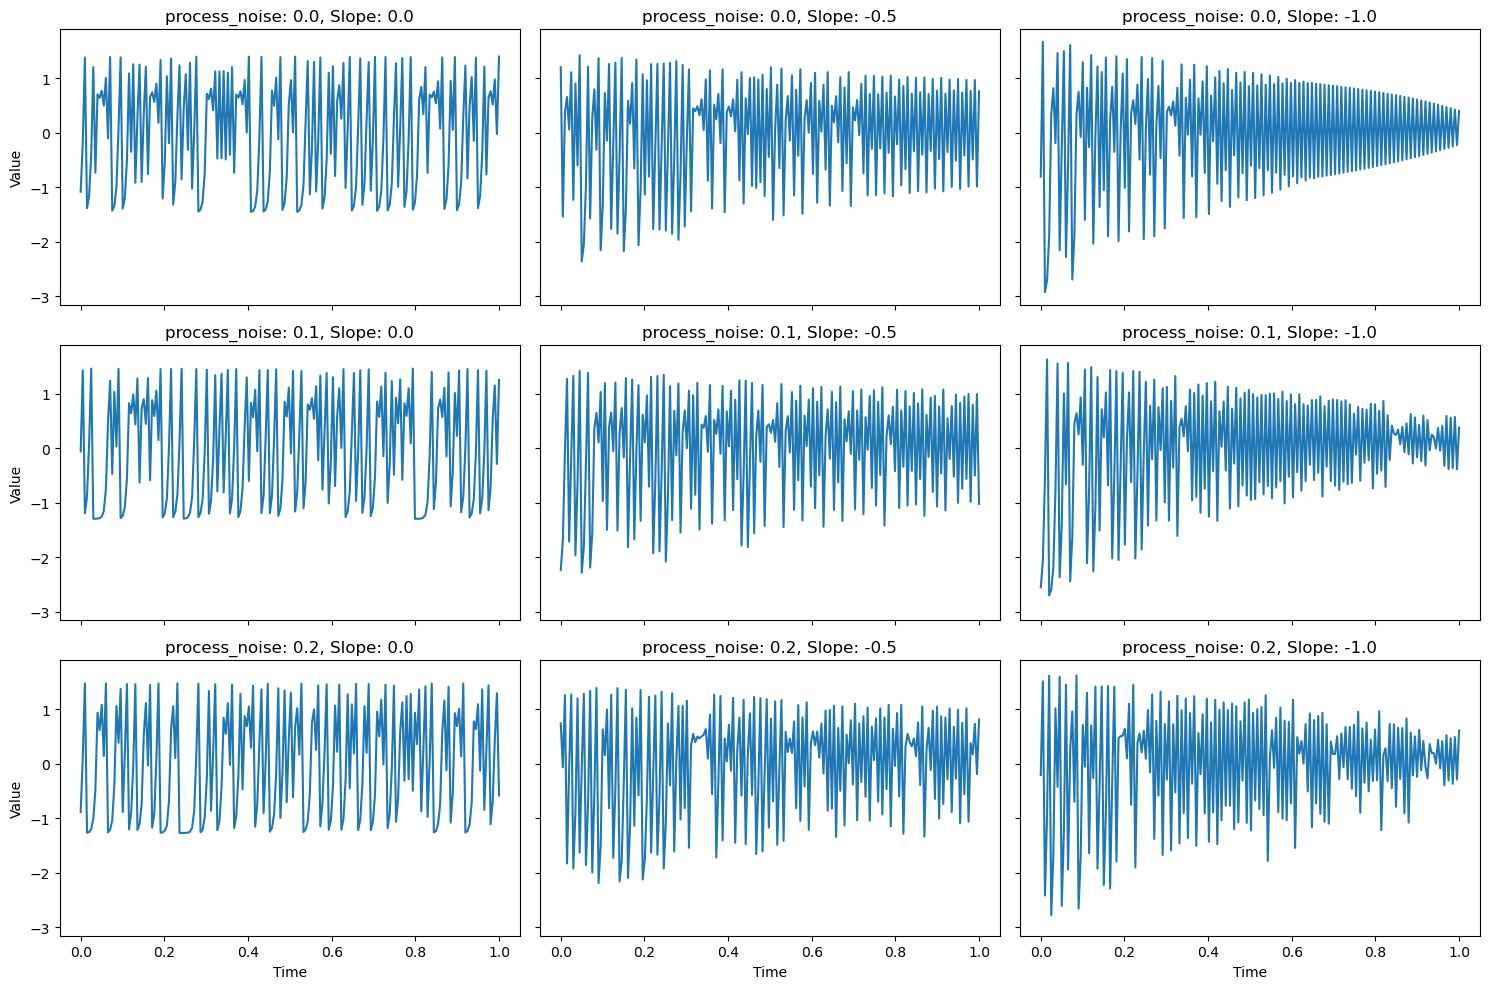

In [12]:
# Plot time series for all logistic map results
def plot_logistic_map_results(experiment_params, generate_function):
    """
    Create a grid of subplots for time series by varying all parameters for logistic map results.

    Args:
        experiment_params: Dictionary containing experiment parameters.
        generate_function: Function to generate time series.
    """
    param_names = ["time_series_length", "obs_noise", "process_noise"]

    for param_name in param_names:
        param_values = experiment_params[param_name]
        slopes = experiment_params["nonstat_param_slope"]

        fig, axes = plt.subplots(len(param_values), len(slopes), figsize=(15, 10), sharex=True, sharey=True)

        for i, param_value in enumerate(param_values):
            for j, slope in enumerate(slopes):
                t = np.linspace(0, 1, param_value if param_name == "time_series_length" else default_length)

                # Pass ordered arguments to the generate function
                time_series = generate_function(
                    param_value if param_name == "time_series_length" else default_length,
                    nonstat_param_base, slope, 
                    default_observation_noise if param_name != "obs_noise" else param_value,
                    default_process_noise if param_name != "process_noise" else param_value
                )

                ax = axes[i, j]
                ax.plot(t, time_series)
                ax.set_title(f"{param_name}: {param_value}, Slope: {slope}")

                if i == len(param_values) - 1:
                    ax.set_xlabel("Time")
                if j == 0:
                    ax.set_ylabel("Value")

        plt.tight_layout()
        plt.show()

# Example usage for logistic map results
plot_logistic_map_results(experiment_params, generate_logistic)

In [13]:
tau = params["tau"]
N_replicates = params["N_replicates"]
resolution = params["resolution"]

experiment_params = params["experiments"][1]["parameters"]

default_length = experiment_params["default_length"]
default_observation_noise = experiment_params["default_obs_noise"]
default_process_noise = experiment_params["default_process_noise"]
nonstat_param_base = experiment_params["nonstat_param_base"]

time_per_step = experiment_params["time_per_step"]
reduction = experiment_params["reduction"]

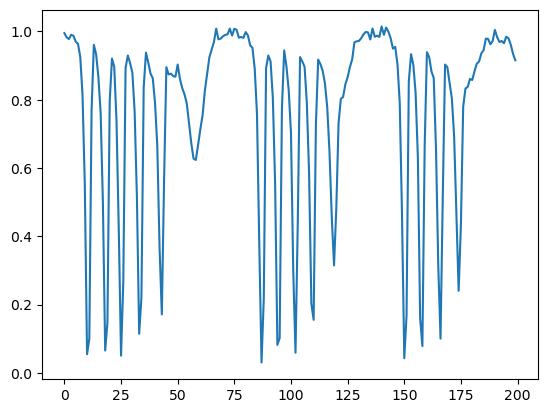

In [8]:
plt.plot(generate_food_chain(200, 5, 0, 0.0, 3e-2))

In [9]:
4e-2

0.04

In [10]:
np.mean(np.array([np.var(generate_food_chain(200, 5, 0, 0.0, 4e-2)) / np.var(generate_food_chain(200, 5, 0, 0.0, 0.0)) for _ in range(20)]))

KeyboardInterrupt: 

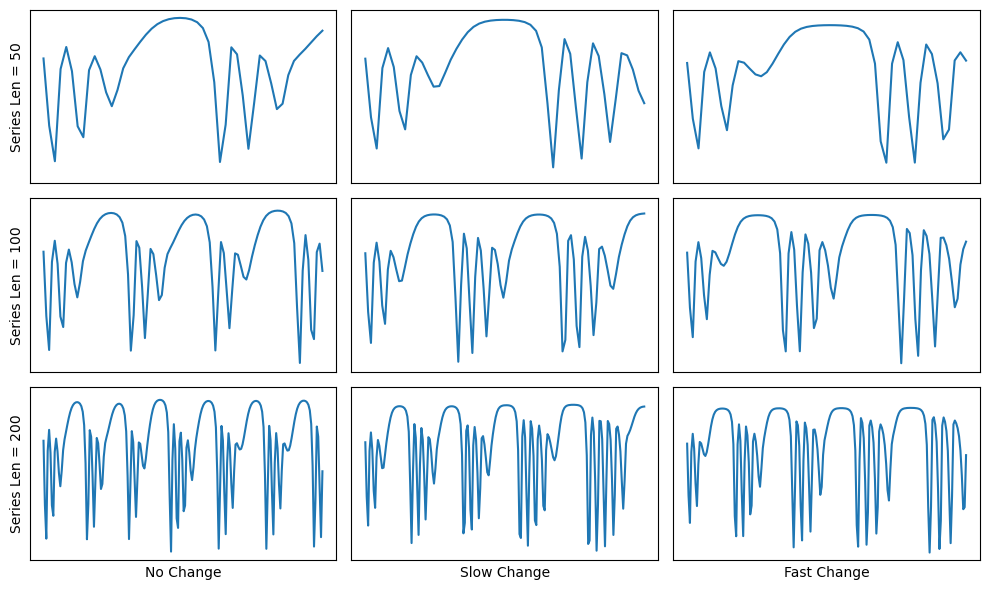

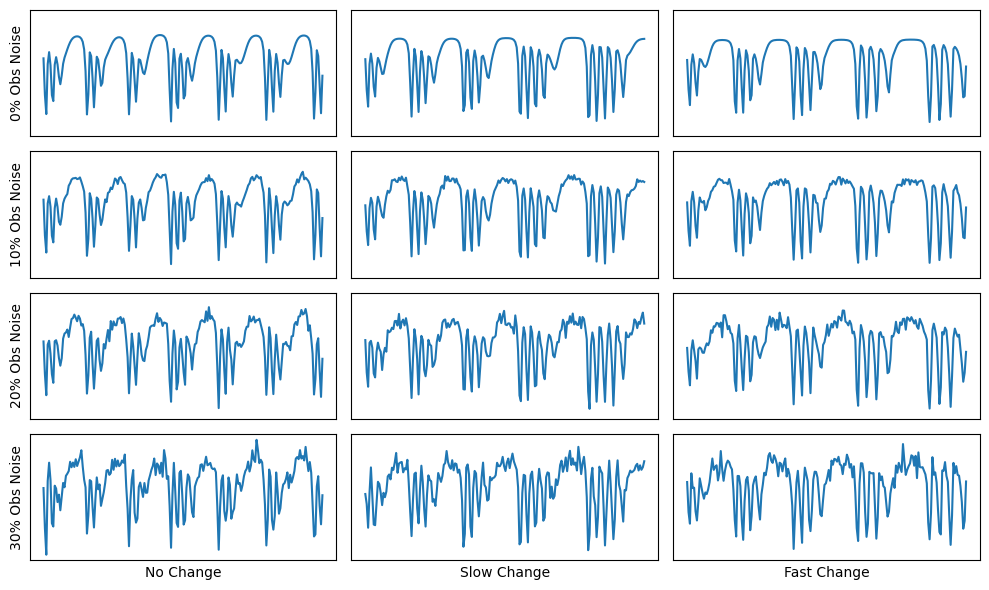

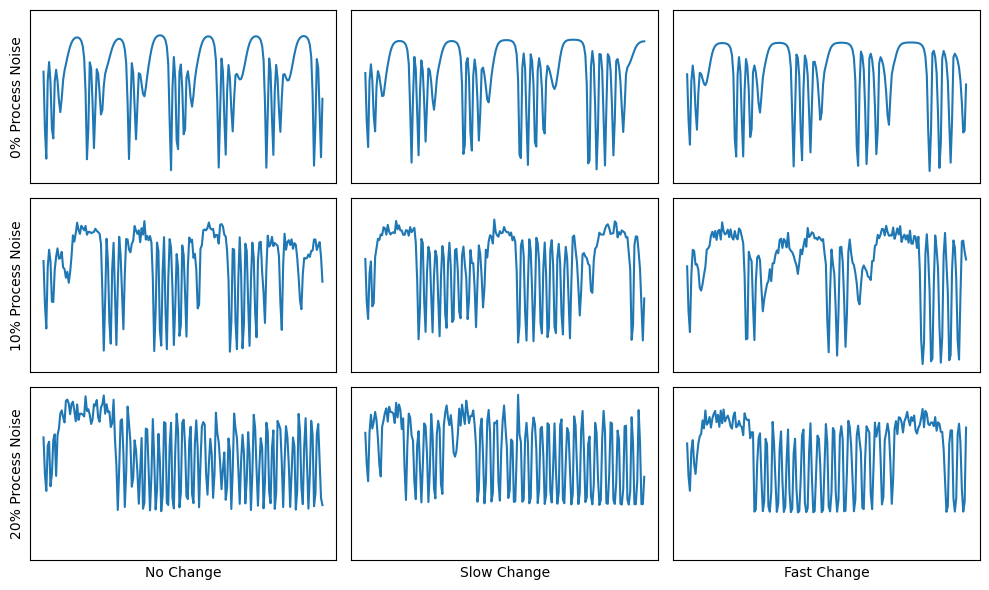

In [14]:
def plot_time_series_by_param(experiment_params, generate_function, param_name, param_values, filename):
    """
    Create a grid of subplots for time series by varying a specific parameter.

    Args:
        experiment_params: Dictionary containing experiment parameters.
        generate_function: Function to generate time series.
        param_name: Name of the parameter being varied (e.g., 'obs_noise', 'process_noise', 'time_series_length').
        param_values: List of values for the parameter being varied.
    """
    slopes = experiment_params["nonstat_param_slope"]

    fig, axes = plt.subplots(len(param_values), len(slopes), figsize=(10, 6), sharex=True, sharey=True)

    for i, param_value in enumerate(param_values):
        for j, slope in enumerate(slopes):
            t = np.linspace(0, 1, param_value if param_name == "time_series_length" else default_length)

            # Pass ordered arguments to the generate function
            time_series = generate_function(
                param_value if param_name == "time_series_length" else default_length,
                nonstat_param_base, slope, 
                default_observation_noise if param_name != "obs_noise" else param_value,
                default_process_noise if param_name != "process_noise" else param_value
            )

            ax = axes[i, j]
            ax.plot(t, time_series)
            # ax.set_title(f"{param_name}: {param_value}, Slope: {slope}")

            if i == len(param_values) - 1:
                if j == 0:
                    axes[i, j].set_xlabel("No Change")
                elif j == 1:
                    axes[i, j].set_xlabel("Slow Change")
                else:
                    axes[i, j].set_xlabel("Fast Change")

            if j == 0:
                if param_name == "time_series_length":
                    axes[i, j].set_ylabel(f"Series Len = {param_value}")
                elif param_name == "obs_noise":
                    axes[i, j].set_ylabel(f"{int(param_value * 100)}% Obs Noise")
                elif param_name == "process_noise":
                    axes[i, j].set_ylabel(f"{int(param_value * 100)}% Process Noise")

            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

    plt.tight_layout()
    # plt.savefig(f"../../figures_eps/example_series/{filename}.eps", format="eps", bbox_inches="tight", transparent = False)
    plt.show()

# Example usage for time series length
plot_time_series_by_param(experiment_params, generate_food_chain, "time_series_length", experiment_params["time_series_length"], "Figure_S6")

# Example usage for observation noise
plot_time_series_by_param(experiment_params, generate_food_chain, "obs_noise", experiment_params["obs_noise"], "Figure_S7")

# Example usage for process noise
plot_time_series_by_param(experiment_params, generate_food_chain, "process_noise", experiment_params["process_noise"], "Figure_S8")

In [10]:
print("Process Noise:", experiment_params["process_noise"])
# Process Noise
for process_noise in experiment_params["process_noise"]:
    t = np.linspace(0, 1, default_length)
    for i, nonstat_slope in enumerate(experiment_params["nonstat_param_slope"]):
        time_series = f(default_length, nonstat_param_base, nonstat_slope, default_observation_noise, process_noise)

Process Noise: [0.0, 0.02, 0.04]


TypeError: '_io.TextIOWrapper' object is not callable

# Evaluate Nonstationarity Test on Different Types of Nonstationarity

In [8]:
with open("parameters_round2.json", "r") as f:
    params = json.load(f)

Function 'generate_logistic' found.


/net/flood/home/kengee/NS-Map/NS-Map/experiments/simulated_round_2/nonlinear_models.py:33: RuntimeWarning: invalid value encountered in log
  u = np.log(x / (1 - x))
/net/flood/home/kengee/NS-Map/NS-Map/utils/TimeseriesToolkit.py:11: RuntimeWarning: invalid value encountered in divide
  return (x - np.mean(x, axis=0, where=np.isfinite(x))) / np.std(x, axis=0, where=np.isfinite(x))


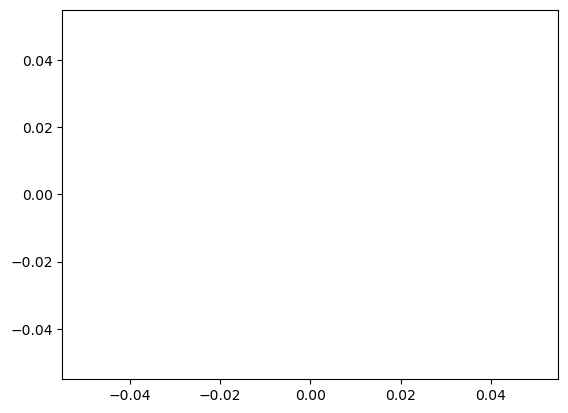

In [9]:
function_name = "generate_"+params["experiments"][0]["name"]
generate_function = globals().get(function_name)

if generate_function:
    print(f"Function '{function_name}' found.")
else:
    print(f"Function '{function_name}' not found.")

plt.plot(generate_function(200, 5, -1.5, 0.0, 0.1))

Function 'generate_logistic' found.


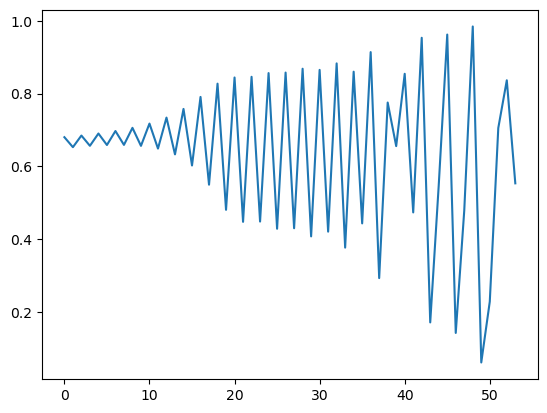

In [19]:
function_name = "generate_"+params["experiments"][1]["name"]
generate_function = globals().get(function_name)

if generate_function:
    print(f"Function '{function_name}' found.")
else:
    print(f"Function '{function_name}' not found.")

plt.plot(generate_function(200, 3, 4, 0.0, 0.0))

FileNotFoundError: logistic.csv not found.

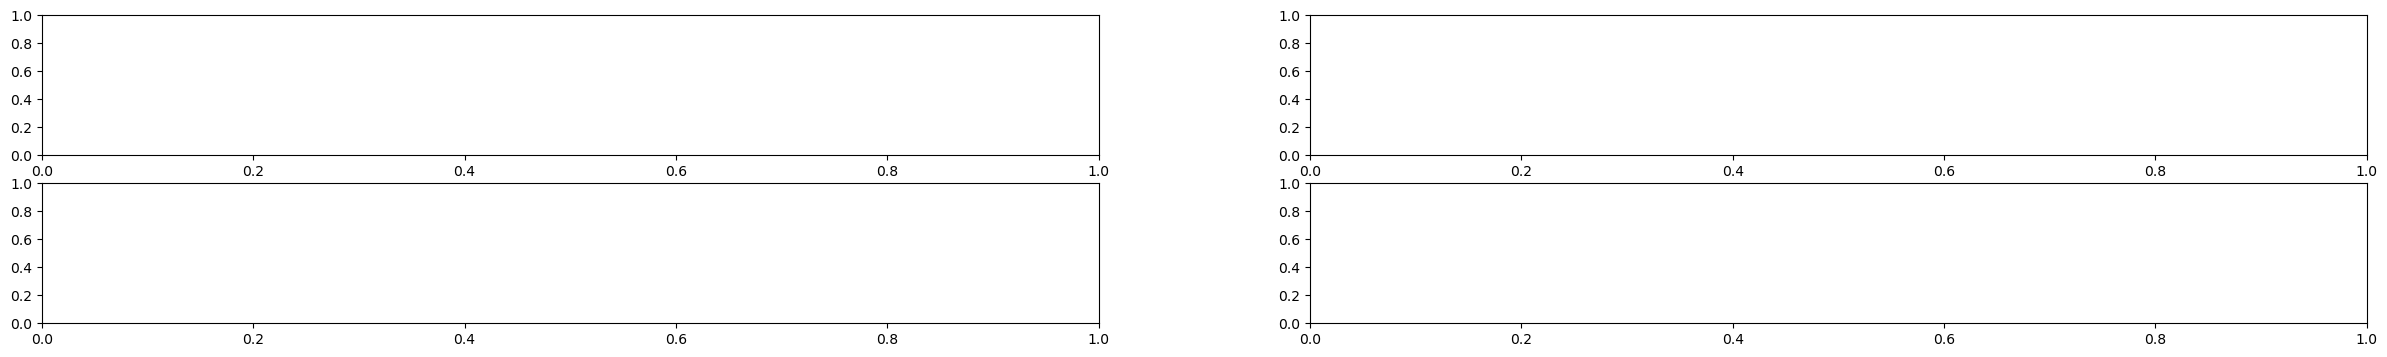

In [23]:
fig, ax = plt.subplots(2, len(params["experiments"]), figsize=(30, 4))

for i, para in enumerate(params["experiments"]):
    data = np.loadtxt(f"{para['name']}.csv", delimiter=",")

    function_name = f"generate_{para['name']}"
    generate_function = globals().get(function_name)

    ax[0, i].plot(generate_function())
    ax[0, i].set_title(para["name"])
    ax[0, i].set_yticks([])
    ax[0, i].set_xticks([])
    ax[0, i].set_xlabel("time")
    ax[1, i].hist(data[:, 0], bins=20, range=(-10, 200))
    ax[1, i].set_yticks([])
    ax[1, i].set_xlabel("Evidence (dB)")

ax[0, 0].set_ylabel("Simulated data")
ax[1, 0].set_ylabel("Frequency")

plt.tight_layout()

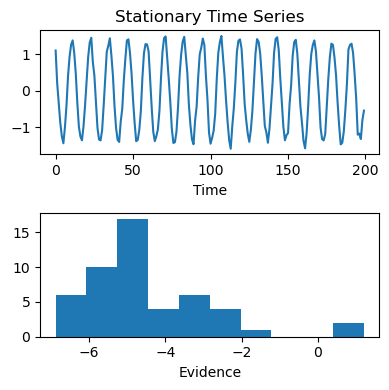

In [ ]:
# Plot the time series on the first subplot
ax[0].plot(generate_stationary_linear())
ax[0].set_title("Stationary Time Series")
ax[0].set_xlabel("Time")
# ax[0].set_ylabel("Value")

# Plot the histogram on the second subplot
ax[1].hist(stationary_data[:, 0], alpha=1.0)
ax[1].set_xlabel("Evidence")

plt.tight_layout()
plt.show()

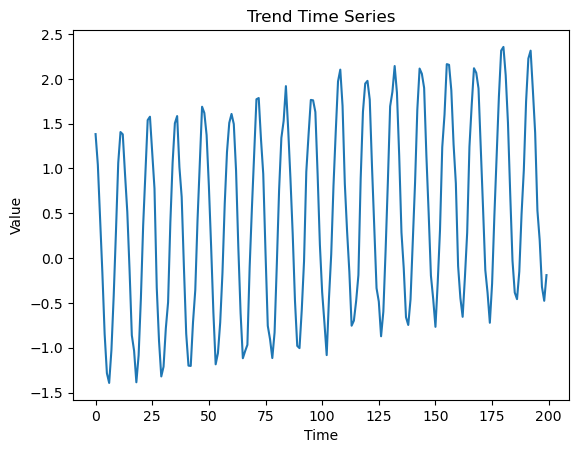

In [62]:
# Plot an example time series from the stationary case

plt.plot(generate_nonstationary_trend_linear())
plt.title("Trend Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

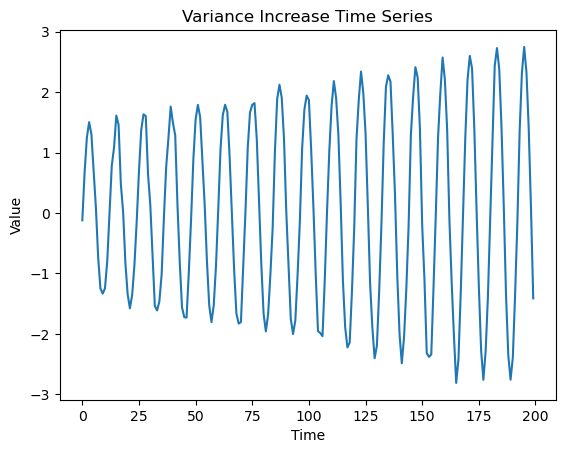

In [66]:
# Plot an example time series from the nonstationary case with increasing variance
plt.plot(generate_nonstationary_variance_increase_linear())
plt.title("Variance Increase Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

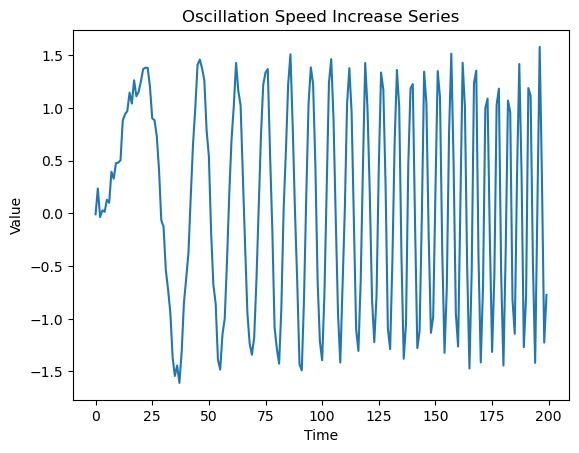

In [69]:
# Plot an example time series from the nonstationary case with increasing variance
plt.plot(generate_nonstationary_oscillation_speed_linear())
plt.title("Oscillation Speed Increase Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

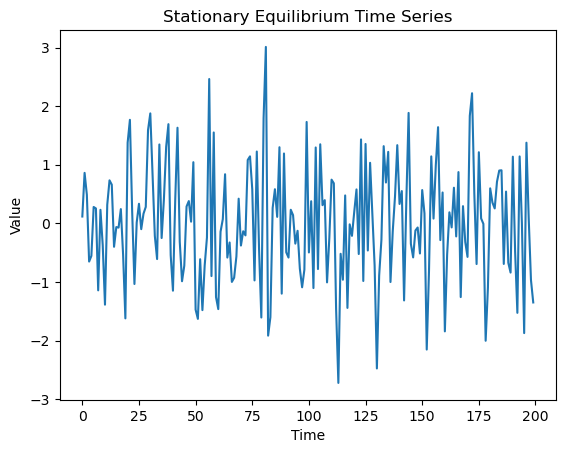

In [73]:
# Plot an example time series from the nonstationary case with increasing variance
plt.plot(generate_stationary_equilibrium())
plt.title("Stationary Equilibrium Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

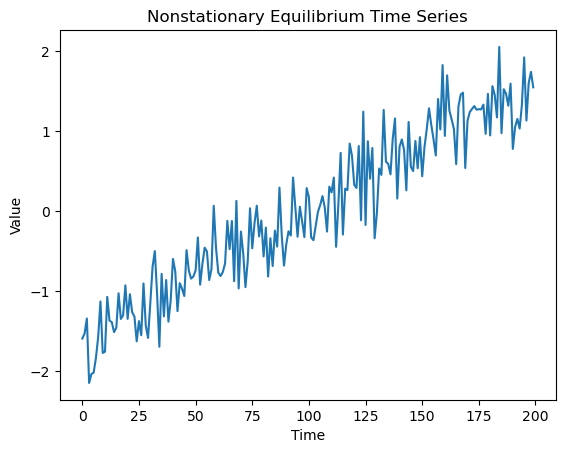

In [76]:
# Plot an example time series from the nonstationary case with increasing variance
plt.plot(generate_nonstationary_equilibrium_trend())
plt.title("Nonstationary Equilibrium Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [202]:
# Results

table = np.loadtxt("../results/linear_results/equilibrium_mean_change_process_noise.csv", delimiter=",")
print(f"Proportion of nonstationary equilibrium Ricker classified as nonstationary: {np.mean(table[:,0] > 0.1)}")

table = np.loadtxt("../results/linear_results/equilibrium_process_noise.csv", delimiter=",")
print(f"Proportion of stationary equilibrium Ricker classified as stationary: {np.mean(table[:,0] < 0.1)}")

Proportion of nonstationary equilibrium Ricker classified as nonstationary: 1.0
Proportion of stationary equilibrium Ricker classified as stationary: 0.71


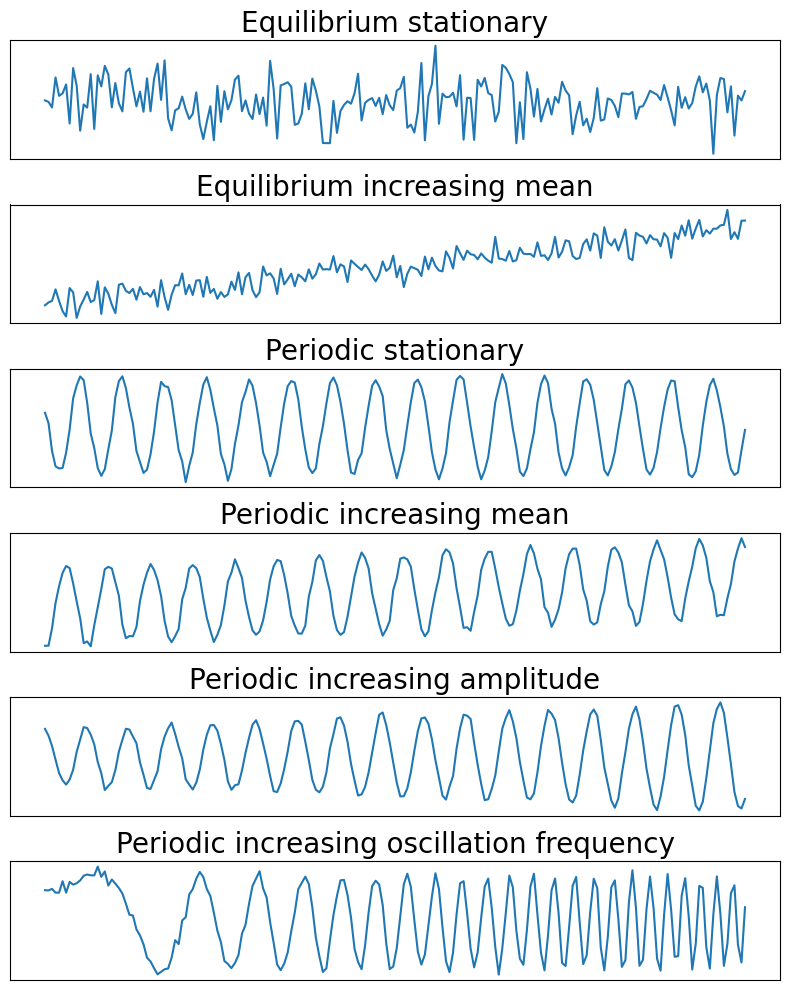

In [77]:
fig, ax = plt.subplots(6,figsize=(8,10))

ax[0].plot(generate_stationary_equilibrium())
ax[0].set_title("Equilibrium stationary", fontsize = 20)
ax[1].plot(generate_nonstationary_equilibrium_trend())
ax[1].set_title("Equilibrium increasing mean", fontsize = 20)
ax[2].plot(generate_stationary_linear())
ax[2].set_title("Periodic stationary", fontsize = 20)
ax[3].plot(generate_nonstationary_trend_linear())
ax[3].set_title("Periodic increasing mean", fontsize = 20)
ax[4].plot(generate_nonstationary_variance_increase_linear())
ax[4].set_title("Periodic increasing amplitude", fontsize = 20)
ax[5].plot(generate_nonstationary_oscillation_speed_linear())
ax[5].set_title("Periodic increasing oscillation frequency", fontsize = 20)

for i in range(6):
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.savefig("Figure_S1.eps", bbox_inches="tight")

# Tanya's Example Systems

In [34]:
generate_autoregressive_time_series()

IndexError: list index out of range

In [29]:
#time
ti=np.arange(100)
#a noisy sinusoid
yi=np.sin(2*np.pi/12*ti)+np.random.normal(0,0.05,100)
#an AR1 with a transient
yii=np.zeros(100); yii[0]=10
a=0.95
for i in range(1,100):
    yii[i]=yii[i-1]*a+np.random.normal(0,0.5)

#AR1 plus the sinusoid
yiii=yi+yii
yvi=yi+0.3*yii

In [30]:
yii

array([10.        ,  9.3587984 ,  8.76066279,  8.35415649,  8.06826737,
        7.76574654,  7.22977703,  7.38183215,  7.06618139,  6.13645826,
        5.43869683,  5.54830537,  5.22642612,  4.77932989,  5.00295724,
        5.07552554,  4.63432445,  4.38641093,  4.35526695,  4.42362712,
        3.77342187,  2.69508524,  2.26235166,  1.97366385,  2.23921646,
        2.6839664 ,  2.87625339,  1.8053585 ,  1.63560341,  1.50638378,
        1.36375125,  0.39620165,  1.32127276,  1.04363169,  2.04276968,
        1.08351476,  1.76304586,  1.98503911,  1.39412804,  0.95059294,
        1.04878092,  0.23772259,  0.0914346 ,  0.49174778,  0.69918852,
        0.78599505,  0.13965419, -0.70239573, -0.43349832, -0.07865216,
        0.29426287,  0.44124324,  0.10958124,  0.2056278 ,  0.12313886,
        0.50472586,  0.10874255,  0.17066846,  0.23360008,  0.4654843 ,
        0.71089418,  0.822722  ,  0.63701959,  1.07622934,  0.68130701,
        1.26220225,  1.33295573,  1.07222017,  0.68309297,  0.68

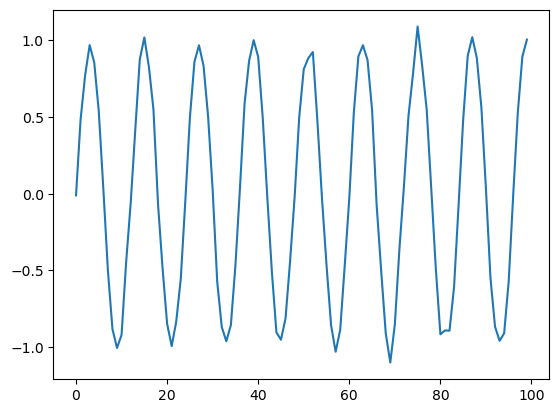

In [24]:
plt.plot(yi)

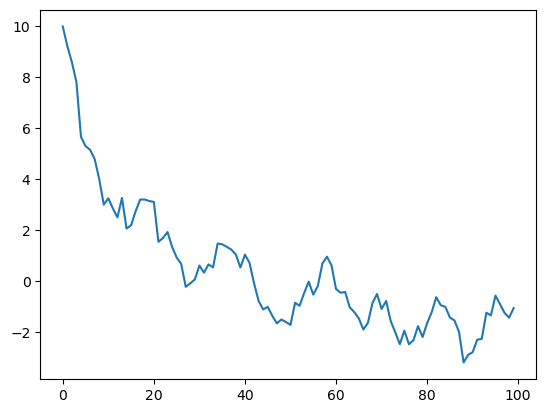

In [25]:
plt.plot(yii)

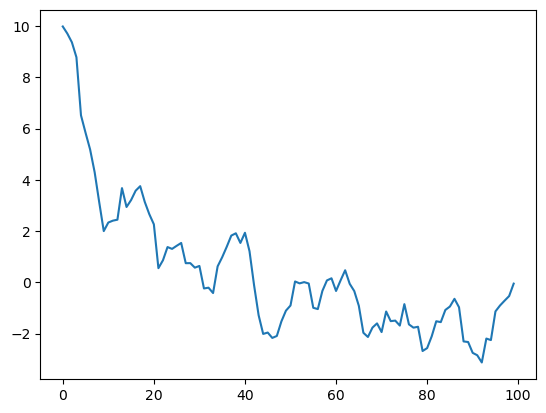

In [26]:
plt.plot(yiii)

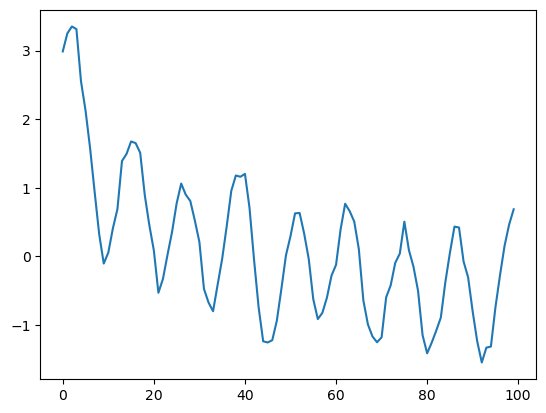

In [27]:
plt.plot(yvi)